<div class='heading'>
    <div style='float:left;'><h1>CPSC 8810: Machine Learning for Graphs</h1></div>
     <img style="float: right; padding-right: 10px" width="100" src="https://raw.githubusercontent.com/bsethwalker/clemson-cs4300/main/images/clemson_paw.png"> </div>
     </div>

**Clemson University**<br>
**Instructor(s):** Aaron Masino <br>

## Lab 4: Graph Neural Networks in Practice
This notebook demonstrates the use of graph neural network (GNN) layers in deep-learning models. It illustrates the use of these layers in combination with node and graph level prediction heads for classification tasks. In each case, the prediction model leverages GNN layers that follow from the message passing framework discussed in class. Three datasets are considered to highlight different tasks and modeling considerations: Cora citation network, TU Dortmund University Enzymes data, and a large synthetic network. Finally, the notebook also introduces use of the [PyTorch Lightning](https://lightning.ai/pytorch-lightning) libray which will support data loading and model training. 

### Learning Objectives
1. Understand the data structures and data handling methods used in PyTorch Geometric and PyTorch Lightning.
2. Apply GNN layers that use message passing as implemented in PyTorch Geometric to develop graph encoding modules.
3. Apply standard neural network layers as implemented in PyTorch to develop prediction head modules.
4. Create deep learning models on graph data by composing GNN and graph encoding and prediction head modules.
5. Apply model parameter tuning and model evaluation to select the best model.
6. Evaluate the performance of deep learning models for node and graph classification tasks. 

In [ ]:
# Data manipulation and analysis
import numpy as np
import pandas as pd
from pathlib import Path
import os

# Graph analysis
import networkx as nx

# PyTorch and PyTorch Geometric
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F
# import torch.nn as tnn so as not to conflict with nn from PyTorch Geometric
from torch import nn as tnn
from torch_geometric.datasets import Planetoid, TUDataset, FakeDataset
from torch_geometric.utils import to_networkx
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader, NeighborLoader
from torch_geometric.transforms import RandomNodeSplit
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, SAGEConv
from torch_geometric.seed import seed_everything

# PyTorch Lightning
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch import seed_everything
import lightning.pytorch.trainer as trainer

import torchmetrics as TM

# Machine Learning
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc)
from sklearn.manifold import TSNE
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Setup
plt.style.use('default')
sns.set_palette("husl")

# Create output directory
output_dir = Path('./output/lab_04')
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory created: {output_dir}")

# data directory
data_dir = Path('../data')
data_dir.mkdir(parents=True, exist_ok=True)

dir_lightning = Path(os.path.join(data_dir, "lightning"))
dir_lightning.mkdir(parents=True, exist_ok=True)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Reusable random state
RANDOM_STATE = 654321
seed_everything(RANDOM_STATE)

# Pandas set max columns to display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### Helper Functions

In [ ]:
def plot_roc_curves(y_true, y_pred_proba, class_names, title="ROC Curves"):
    """
    Plot ROC curves for multi-class classification
    
    Args:
        y_true: True labels (numpy array or tensor)
        y_pred_proba: Predicted probabilities for each class (numpy array or tensor)
        class_names: List of class names
        title: Plot title
    """
    
    # Convert to numpy if tensors
    if torch.is_tensor(y_true):
        y_true = y_true.cpu().detach().numpy()
    if torch.is_tensor(y_pred_proba):
        y_pred_proba = y_pred_proba.cpu().detach().numpy()

    # Binarize the labels for multi-class ROC
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    
    plt.figure(figsize=(8,6))
    colors = [f'C{i}' for i in range(len(class_names))]
    
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], lw=2, 
                 label=f'{class_names[i]} (AUC = {roc_auc:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.500)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    """
    Plot confusion matrix with class names
    
    Args:
        y_true: True labels (numpy array or tensor)
        y_pred: Predicted labels (numpy array or tensor)
        class_names: List of class names
        title: Plot title
    """
    
    # Convert to numpy if tensors
    if torch.is_tensor(y_true):
        y_true = y_true.cpu().numpy()
    if torch.is_tensor(y_pred):
        y_pred = y_pred.cpu().numpy()
    
    cm = confusion_matrix(y_true, y_pred, normalize='pred')
    
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    

---
# Part 1: Node classification with a graph convolutional networks
Graph convolutional networks are one type of GNN in the message passing framework. Among their defining features are:(1) they aggregate messages from all of a given node's neighbors; and (2) they apply equal weight to each node neighbor. 

Here, we will revisit the [Cora citation dataset](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.Planetoid.html#torch_geometric.datasets.Planetoid) that we examined in the previous lab. The dataset is taken from the  “[Revisiting Semi-Supervised Learning with Graph Embeddings](https://arxiv.org/abs/1603.08861)” paper. Each node corresponds to a published article, and the edge between two nodes represent citations. Unlike the previous lab, here we will leverage not only the graph structure, but also the node features.

## 1.1 Load the Cora dataset
First, let's load the dataset. During loading, we will apply the `RandomNodeSplit` transform as we did in the previous lab to generate training, vaidation, and test splits. 

**Dataset Properties:**

The Cora dataset consists of a **single graph**. 
- **Classes**: 7 different article categories - the categories are subsets of machine learning topics:
    1. Case Based
    2. Genetic Algorithms
    3. Neural Networks
    4. Probabilistic Methods
    5. Reinforcement Learning
    6. Rule Learning
    7. Theory
- **Features**: Each node has a feature vector that is the bag-of-words embedding for the article using a dictionary of 1,433 words. These will form the initial node feature input in our GCN model.
- **Data split**: We use a __transductive__ node split. The entire graph will be available for message passing and embedding update during both training and evaluation. However, only the training node labels will be available for training. Validation and test node labels will only be available during validation and test evaluation, respectively. We follow the same approach as in the previous lab using the PyG [RandomNodeSplit](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.transforms.RandomNodeSplit.html) transformer to form the data splits.

In [ ]:
cora = Planetoid(root=f'{data_dir}', name='Cora', split='public')
cora_data = cora[0]  # Get the first (and only) graph
cora_labels = ['Case Based', 'Genetic Algorithms', 'Neural Networks',
               'Probabilistic Methods', 'Reinforcement Learning',
               'Rule Learning', 'Theory']
seed_everything(RANDOM_STATE)
transform = RandomNodeSplit(num_train_per_class=10, num_val=250, num_test=600, split='train_rest')

# Apply the transform to create new masks
cora_data = transform(cora_data)
    
print("=== Cora Dataset ===")
print(f"Number of graphs in dataset: {len(cora)}")
print("Keys in the dataset:", cora_data.keys())

print("\n=== Cora Dataset's First (and only) Graph ===")
print(f"Number of nodes: {cora_data.num_nodes}")
print(f"Number of edges: {cora_data.num_edges}")
print(f"Number of node features: {cora_data.num_node_features}")
print(f"Number of classes: {cora.num_classes}")

# print size of training, validation, test splits
print(f"Number of training samples: {cora_data.train_mask.sum()}")
print(f"Number of validation samples: {cora_data.val_mask.sum()}")
print(f"Number of test samples: {cora_data.test_mask.sum()}")

## 1.2 Node classification model with GCN layers
Here, we will develop a model that consists of two GCN layers (the GNN layers) followed by a linear layer (the prediction head). To keep things simple, we will combine these into a single model. 

We will implement the GCN layers using the PyG [GCNConv](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GCNConv.html#torch_geometric.nn.conv.GCNConv) class which is an efficient implementation of the standard graph convolutional network layer introduced in class. The key inputs are:
*   `in_channels`: the size of the input. For the first GCN this is the size of the bag of words features, `x`, in the dataset. In subsequent layers, it is the size of the embedding provided by the previous layer.
*   `out_channels` : the size of the embedding created by the GCN
*   `normalize` : whether to add self loops, default: `TRUE`. This ensures the node passes its on embedding into the message aggregation

We will also include a nonlinearity, `ReLU`, after each GCN layer and `dropout` to provide regularization during the learning process. 

Finally, we add a linear layer to project the embeddings from the final GCN layer to a C-dimensional vector where C is the number of node classes in the Cora dataset.

In [ ]:
class GCNClassifier(tnn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCNClassifier, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.fc = tnn.Linear(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.fc(x)

        return x

Now that we've defined our model, we are ready to train. We will first instantiate an instance of our `GCNClassifier` class specifying the `in_channels` to match the node feature size in the Cora dataset and the `out_channels` to the number of node class labels in the Cora dataset. We specify the desired final node embedding dimension using the `hidden_channels` argument.

We want to first be sure to leverage our GPU if available by moving the model and data to the GPU device. 

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
seed_everything(RANDOM_STATE)

model = GCNClassifier(in_channels=cora_data.num_node_features,
                hidden_channels=16,
                out_channels=cora.num_classes).to(device)
data = cora_data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

model.train()
max_epochs = 200
for epoch in range(max_epochs):
    optimizer.zero_grad()
    out = model(data)
    # loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Loss: {loss.item():.4f}")

Let's take a peek at how this model performs on the validation set. We don't want to use the test set because we will want to evaluate tuning parameters, namely the number of hidden dimensions (i.e., the node embedding dimension) and we should not use the test set untile we've finalized our model selection.

In [ ]:
model.eval()
pred = model(data).argmax(dim=1)
correct = (pred[data.val_mask] == data.y[data.val_mask]).sum()
acc = int(correct) / int(data.val_mask.sum())
print(f'Accuracy: {acc:.4f}')

The model accuracy is already fairly good. Let's see if we can do better.

<p style="font-size: 22px; color: Tomato"><strong>Excercise 1.1</strong></p>

Is the node embedding size of 16 we used above the best choice? This is a hyperparameter of the model that we should tune (there are others, but let's just focus on one). 

In the code cell below, replace the `None` values to complete the implementation of the grid search over different values for the `hidden_channels` input to the `GCNClassifier`. This cell will test the values in the `hidden_dims` list. The best model will be selected based on the validation loss - this is the typical approach, though not the only one. For example, prediction accuracy on the validation set can be used.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
hidden_dims = [16, 32, 64, 128, 256, 512]
best_val_loss = float('inf')
best_dim = None # do not change
best_model = None # do not change
for dim in hidden_dims:
    seed_everything(RANDOM_STATE)
    #### YOUR CODE HERE ####
    
    model = None
    
    data = cora_data.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    max_epochs = 200
    model.train()
    for epoch in range(max_epochs):
        optimizer.zero_grad()
        out = model(data)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        
    # check the model on the validation set
    with torch.no_grad():
        loss = F.cross_entropy(out[data.val_mask], data.y[data.val_mask])

    if loss.item() < best_val_loss:
        #### YOUR CODE HERE ####
        best_val_loss = None
        best_dim = None
        best_model = None
    
    print(f"Validation loss for hidden dimension {dim}: {loss.item():.4f}")

print(f"Best hidden dimension: {best_dim}, Validation Loss: {best_val_loss:.4f}")

model = best_model

## 1.3 Model evaluation
Now that we've selected the hidden dimension size, let's evaluate the model on the test set. We will review the classification report, confusion matrices, and class ROC curves as we did in the previous lab with `node2vec` embeddings. We will then compare these to the results obtained using `node2vec` embeddings. We expect (okay, hope) to observe significant improvement.

In [ ]:
# test predictions and probabilities
model.eval()
with torch.no_grad():
    proba = model(data)[data.test_mask]
    preds = proba.argmax(dim=1)

# Convert tensors to numpy arrays, ensuring they're on CPU first
y_test_np = data.y[data.test_mask].cpu().numpy()
test_pred_np = preds.cpu().numpy()
test_proba_np = proba.cpu().numpy()

print("Classification Report:")
print(classification_report(y_test_np, test_pred_np, target_names=cora_labels, digits=4))

# ROC curves for each class - functions now handle device conversion automatically
plot_roc_curves(y_test_np, test_proba_np, cora_labels,
                title="ROC Curves By Class")

# Confusion matrix - functions now handle device conversion automatically
plot_confusion_matrix(y_test_np, test_pred_np, cora_labels,
                     title="Confusion Matrix")

How does this compare to the best model we found using `node2vec` embeddings? Below are the performance metrics for the best of the Cora node prediction models generated in the previous lab. Indeed we see that the results for our new GNN model are better. Why do you think this is the case?

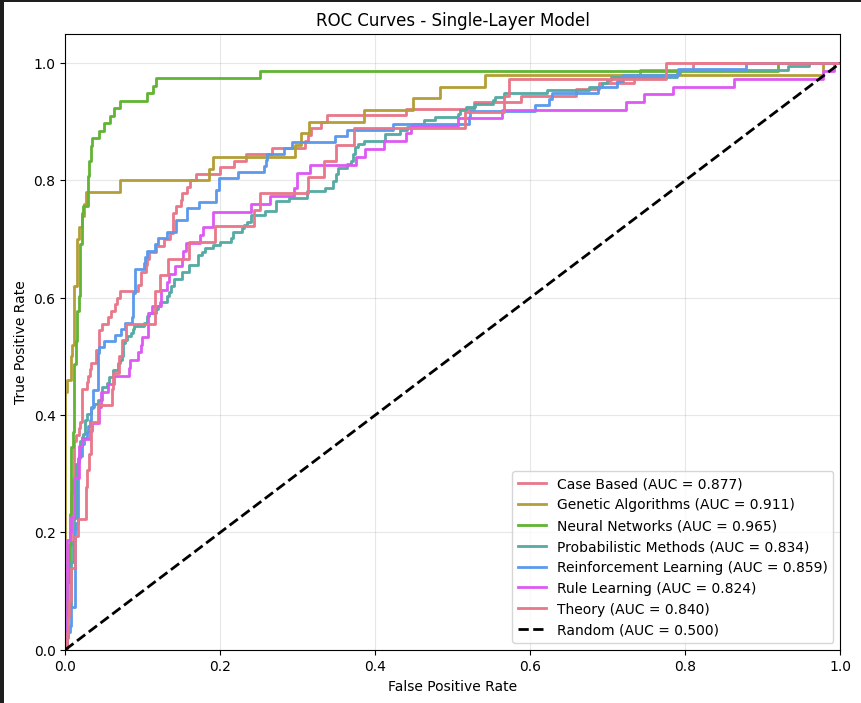

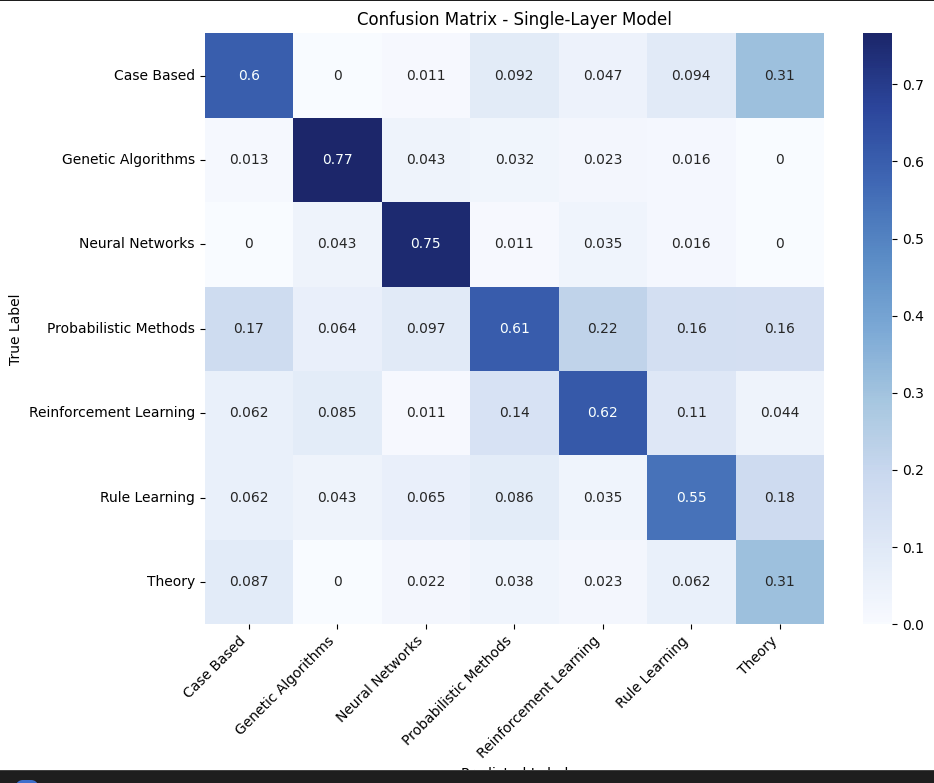

---

# Part 2: Graph classification with graph attention network
Graph attention (GAT) networks are another important type of GNN in the message passing framework. Unlike standard GCN, message aggregation in GAT layers is weighted. The contribution of each input node message is weighted by a learnable attention weight. 

Here, we will develop a model to classify input graphs representing the structure of enzymes. We will also introduce a more robust modeling framework in which we will develop two module layer classes, one for the GNN encoder and one for the prediciton head. We will also introduce feature of the PyTorch Lightning library that will reduce the amount of boiler plate code we need to create.

## 2.1 Load the Enzymes dataset
First, let's load the ENZYMES dataset from the PyTorch Geometric [TUDataset](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.TUDataset.html#torch_geometric.datasets.TUDataset) module. The dataset consists of 600 graphs. Each node has 3 features, though interestingly there seems to be no online documentation on what they represent. However, we can examine the distinct values of the features to get a sense of the type of variable represented by the feature. It turns out that each feature is binary.

In [ ]:
enz = TUDataset(root=f'{data_dir}', name='ENZYMES')
enz_class_map={0: 'Oxidoreductases', 1: 'Transferases', 2: 'Hydrolases', 3: 'Lyases', 4: 'Isomerases', 5: 'Ligases'}

print(f'Dataset: {enz}:')
print('====================')
print(f'Number of graphs: {len(enz)}')
print(f'Number of features: {enz.num_features}')
print(f'Number of classes: {enz.num_classes}')

# lets find the number of distinct values for each node feature across all graphs and print the distinct values
for i in range(enz.num_features):
    num_distinct = enz.x[:, i].unique()
    print(f'Feature {i}: {num_distinct} distinct values')

print("\nFirst graph")
print(enz[0])

## 2.2 Batching graphs for model training

Although there are many graphs in our dataset, each graph is relatively small. We would like to batch these during training to improve learning and maximize our GPU utilization. However, as we might expect, our graphs have variation in the number of nodes. This is similar to what is encountered in natural language processing models where text samples have variable numbers of tokens. In that setting, we pad samples shorter than the maximum length sequence with `<pad>` tokens to increase their length to that of the maximum length sequence. This approach doesn't work for graphs. **Why?**

Instead, we will utilize the notion of a `sparse diagonal block matrix` to _stack the adjacency matrices_ of the samples in our batch. Recall, that in the message passsing scheme, messages are aggregated and passed to neighbor nodes based on the adjacency matrix. For example in graph convolutional layers, the adjacency matrix is multiplied by the feature (embedding) matrix to propagate messages (i.e., node features) between neighboring nodes. In graph attention layers, the messages are also aggregated based on neighbors using the adjacency matrix. In each case, messages can only be passed to nodes within the same graph component (i.e., the set of nodes that are reachable to all nodes in the set). For a batch of graphs, we can combine their individual adjacency matrices into a single block matrix and process it through the GNN layers. Importantly, the block matrix representation is _diagnoal_ meaning that off block entries are all zero. This places each graph in the batch in a separate component and prevents information from propagating between nodes of different graphs in the batch regardless of the network depth.

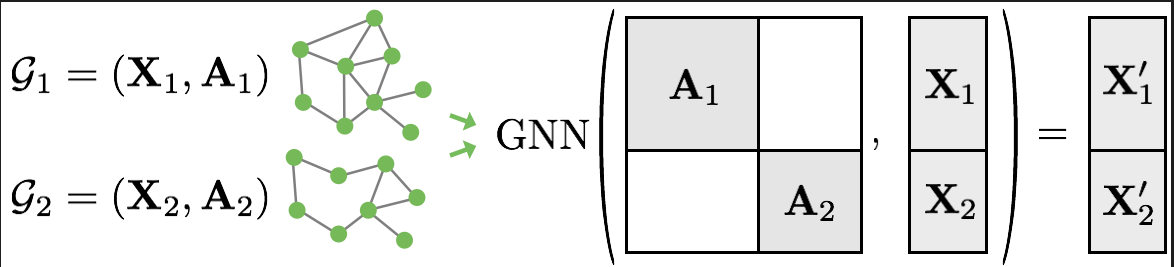>

_Block matrix representation for two graphs. (Image credit, [PyG documentation](https://colab.research.google.com/drive/1I8a0DfQ3fI7Njc62__mVXUlcAleUclnb?usp=sharing#scrollTo=mHSP6-RBOqCE))_

Fortunately, PyG handles this batching procedure for us in the [torch_geometric.loader.DataLoader](https://pytorch-geometric.readthedocs.io/en/latest/modules/loader.html#torch_geometric.loader.DataLoader) class.

Let's look at some batches for our dataset.

In [ ]:
loader = DataLoader(enz, batch_size=32, shuffle=True)

cnt = 0
max_cnt = 3
for step, data in enumerate(loader):
    print(f'Step {step + 1}:')
    print('=======')
    print(f'Number of graphs in the current batch: {data.num_graphs}')
    print(data)
    print()
    cnt += 1
    if cnt == max_cnt:
        break

Note that the dataloader provides a `DataBatch` object representing each batch. In each batch, we can immediately see that the number of samples (batch size) is 32. This is reflected also in the structure of the data where we see that the target data `y` has 32 entries. 

We also see that the node feature data, `x` has been stacked into a single 2D matrix that contains the features for all nodes in the **batch**. Later, we will want to aggregate the tensors representing the nodes of an individual graph to create an overall graph representation for classification. To support this, the `DataBatch` object also includes a `batch` tensor which contains the graph index for each node index in `x` for each node, that is `x[i]` is the feature vector of node `i` which belongs to graph `batch[i]`. The `ptr` tensor contains a monotonically increasing list of integers that represent the node indicies corresponding to each graph, i.e., for the first graph in the batch, the nodes of that graph have indicies in `x` that span `range(ptr[0],ptr[1])`. For example, imagine we have three graphs with 3, 4, and 3 nodes, respectively. Assume each has `k` features. We would have the following:

`x.shape=[10, k]` 

`batch = [0, 0, 0, 1, 1, 1, 1, 2, 2, 2]`

`ptr = [0, 3, 7, 10]`

The nodes that belong to graph `i` are those in `x[ptr[i]:ptr[i+1]]`

The `batch` and `ptr` data elements are important when it is necessary to aggregate node features to form an overall represenation of the graph as for classification.

## 2.3 PyTorch Lightning Data Module

Now that we can use the `DataLoader` class to create graph batches, we still need to split our data into training, validation, and test sets. We will need a separate `DataLoader` for each of the data splits. It will be convenient to have a single object that handles all of this functionality. This is where the PyTorch Lightning `LightningDataModule` class comes in, see [here](https://lightning.ai/docs/pytorch/stable/data/datamodule.html). It will hold the necessary DataLoader objects, prepare data as needed with in a custom `setup` method and, if needed, prepare `mini-batch` samples before sending them to the model (not shown here, we'll see this when working with text data).

Here, we create an extension of the `LightningDataModule` class our dataset. It will split the data into three sets and construct the data loaders.


In [ ]:
class GraphBatchDataModule(L.LightningDataModule):
    def __init__(self, dataset, dataset_name, batch_size=32, test_fraction = 0.2, val_fraction = 0.1, shuffle = True,
                 class_name_map = None):
        super().__init__()
        self.batch_size = batch_size
        self.test_fraction = test_fraction
        self.val_fraction = val_fraction
        self.class_name_map = class_name_map
        self.num_classes = None
        self.shuffle = shuffle
        self._setup(dataset, dataset_name)

    def _setup(self, dataset, dataset_name, stage=None):
        self.dataset = dataset
        self.dataset_name = dataset_name
        self.num_classes = self.dataset.num_classes
        self.num_features = self.dataset.num_features

        test_size = int(len(self.dataset) * self.test_fraction)
        train_size = len(self.dataset) - test_size
        val_size = int(train_size * self.val_fraction)
        train_size = len(self.dataset) - test_size - val_size

        train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
            self.dataset, [train_size, val_size, test_size])
        
        self._train_dataloader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        self._val_dataloader = DataLoader(val_dataset, batch_size=self.batch_size,)
        self._test_dataloader = DataLoader(test_dataset, batch_size=self.batch_size)

    def train_dataloader(self):
        return self._train_dataloader

    def test_dataloader(self):
        return self._test_dataloader
    
    def val_dataloader(self):
        return self._val_dataloader

Let's make sure our data module works correctly.

In [ ]:
dm = GraphBatchDataModule(enz, 'ENZYMES', batch_size=32, class_name_map=enz_class_map)
loader = dm.train_dataloader()

cnt = 0
max_cnt = 2
for step, data in enumerate(loader):
    print(f'Step {step + 1}:')
    print('=======')
    print(f'Number of graphs in the current batch: {data.num_graphs}')
    print(data)
    print()
    cnt += 1
    if cnt == max_cnt:
        break

## 2.4 Graph classification with graph attention and skip connections

Here, we will develop a model that consists of an arbitrary number of graph attention layers (encoder) followed by a linear layer (the prediction head). We will implement these in separate classes which will allow us to experiment with different combinations of GNN layers in the encoder while reusing the prediction head. In particular, we will consider an encoder that uses only GAT layers, and second encoder that inludes skip connections.

We will implement the GCN layers using the PyG [GATConv](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GATConv.html#torch_geometric.nn.conv.GATConv) class implements teh learnable graph attention weights discussed in class and performs aggregation by summing the weighted node features (convolution). The key inputs are:
*   `in_channels`: the size of the input. For the first GAT layer, this is the size of the input feature, `x`, in the dataset. In subsequent layers, it is the size of the embedding provided by the previous layer.
*   `out_channels` : the size of the embedding created by the GAT layer
*   `heads` : the number of attention heads to include
*   `concat` : If set to `FALSE`, the multi-attention heads are averaged, otherwise they are concatenated. We will use the average as this will reduce the number of parameters in our network.

We will also include a nonlinearity, `ReLU`, after each GCN layer and `dropout` to provide regularization during the learning process. 

In [ ]:
class GatEncoder(tnn.Module):
    def __init__(self, node_feature_dim, num_hidden_layers, hidden_channels, heads=1):
        super().__init__()
        self.hidden_layers = tnn.ModuleList()
        self.hidden_layers.append(GATConv(node_feature_dim, hidden_channels, heads=heads, concat=False))
        for i in range(num_hidden_layers - 1):
            self.hidden_layers.append(GATConv(hidden_channels, hidden_channels, heads=heads, concat=False))

    def forward(self, x, edge_index):
        for layer in self.hidden_layers:
            x = layer(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, training=self.training)
        return x

# Create an instance of the encoder for testing
encoder = GatEncoder(dm.num_features, 2, 8, heads=1)

# Test the encoder
sample_batch = next(iter(dm.train_dataloader()))
print("input shape",sample_batch)
encoder_output = encoder(sample_batch.x, sample_batch.edge_index)
print("Output shape:", encoder_output.shape)

<p style="font-size: 22px; color: Tomato"><strong>Excercise 2.1</strong></p>

As discussed in class, we may want to create a GNN encoder with many layers. However, this can lead to over-smoothing of the node embeddings. One approach to address this is to add skip connections. In this exercise, you will complete the code cell below to add a skip connection from the output of each layer to the output of the final GNN layer. The set of outputs, one from each GNN layer, will then be summed element wise to form the overall output of the encoder. 

In [ ]:
class GatSkipEncoder(tnn.Module):
    def __init__(self, node_feature_dim, num_hidden_layers, hidden_channels, heads=1):
        super().__init__()
        self.hidden_layers = tnn.ModuleList()
        self.hidden_layers.append(GATConv(node_feature_dim, hidden_channels, heads=heads, concat=False))
        for i in range(num_hidden_layers - 1):
            self.hidden_layers.append(GATConv(hidden_channels, hidden_channels, heads=heads, concat=False))

    def forward(self, x, edge_index):
        # store layer outputs for skip connections
        skip_connections = []
        for layer in self.hidden_layers:
            x = layer(x, edge_index)
            x = F.relu(x)
            
            #### YOUR CODE HERE ####
            # hint: you need to store the layer outputs in skip_connections

        # sum the skip connections
        return sum(skip_connections)

# Create an instance of the encoder for testing
encoder = GatSkipEncoder(dm.num_features, 2, 8, heads=5)

# Test the encoder
sample_batch = next(iter(dm.train_dataloader()))
print("input shape",sample_batch)
encoder_output = encoder(sample_batch.x, sample_batch.edge_index)
print("Output shape:", encoder_output.shape)

Now we can create a class for the prediction head. We will use a linear layer to project the embeddings created by the encoder to a C-dimensional vector where C is the number of node classes in our dataset. Note, one can create more complex prediction heads. There is no requirement for it to only use a single linear layer.

Notice that the input to the `forward` method of the prediction head is the output from the encoder which is a `[n, embedding_dim]` tensor containing the embeddings of all the nodes across all of the graphs in the batch. This implies that the prediction head `forward` method must be able to aggregate the node embeddings for each graph. Here, we will use the PyTorch Geometric [global_mean_pool](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.pool.global_mean_pool.html#torch_geometric.nn.pool.global_mean_pool) method which will take the element wise average of the node embeddings for each graph. The result is a single embedding for each graph in the batch. To support this, it is necessary for to pass the `batch` variable to the `forward` method. Fortunately, the data loader will provide this.

In [ ]:
class GatBinaryPredictionHead(tnn.Module):
    def __init__(self, hidden_channels, num_classes):
        super().__init__()
        self.linear = tnn.Linear(hidden_channels, num_classes)

    def forward(self, x, batch):
        x = global_mean_pool(x, batch) # batch size x latent_dim
        x = F.dropout(x, p=0.5, training=self.training) # include dropuout regularization
        x = self.linear(x) # pass through the linear layer for logits
        return x


## 2.5 Model construction and training with PyTorch Lightning

Now that we have defined the individual components of our model, we need to assemble them. Just as with our data handlers, it will prove convenient to hold our model components in a single object that also provides methods that support model training and inference. It turns out that for deep learning models, there are repeatable coding patterns that have emerged. These are abstracted in the PyTorch Lightning `LightningModule` class, see [here](https://lightning.ai/docs/pytorch/LTS/common/lightning_module.html). 

To build our custom `LightningModule` class, we will need to define the following methods:

1. `__init__` : define any attributes or setup procedures. This will include our model component modules.
2. `forward` : this will pass an input sample (or mini-batch) through our component modules
3. `training_step` : defines what steps to perform for each training step (i.e. mini-batch). Typically, passing a mini-batch through the network and computing the loss. 
4. `validation_step` : defines what steps to perform for each validation step. Typically, passing a mini-batch through the network and computing the loss
5. `test_step` : defines what steps to perform for each test step. Typically, passing a mini-batch through the network and computing the loss
6. `on_validation_epoch_end` : defines what steps to perform an the end of a validation epoch (i.e., after all validation mini-batches have been evaluated by the model). This often includes a test for halting model training.
7. `on_test_epoch_end` : defines what steps to perform an the end of a test epoch (i.e., after all test mini-batches have been evaluated by the model). This often includes storing metric values.
8. `configure_optimizers` : define the optimization class for use in gradient descent. There are many optimizers available (we'll discuss this more in lecture). Here we use the popular Adam optimizer.

The `LigtningModule` class will use the `training_step` method and the `optimizer` provided by the `configure_optimizer` method to handle updating the model parameters. We do NOT need to implement any code for that part.

Note that in our implementation below, we are using the `TorchMetrics`, see [here](https://lightning.ai/docs/torchmetrics/stable/) library. the `MetricTracker` and associated metrics classes will do all the work for us in calculating and storing model performance metrics on the validation and test mini-batches. We will be able to use these to assess model performance.

In [ ]:
class GatClassifier(L.LightningModule):
    def __init__(self, encoder, pred_head, num_classes):
        super().__init__()
        # model layers
        self.encoder = encoder
        self.pred_head = pred_head

        # validation metrics
        self.val_metrics_tracker = TM.wrappers.MetricTracker(TM.MetricCollection([TM.classification.MulticlassAccuracy(num_classes=num_classes)]))
        self.validation_step_outputs = []
        self.validation_step_targets = []

        # test metrics
        self.test_roc = TM.ROC(task="multiclass", num_classes=num_classes, ) # roc and cm have methods we want to call so store them in a variable
        self.test_cm = TM.ConfusionMatrix(task='multiclass', num_classes=num_classes)
        self.test_metrics_tracker = TM.wrappers.MetricTracker(TM.MetricCollection([TM.classification.MulticlassAccuracy(num_classes=num_classes), 
                                                            self.test_roc, self.test_cm]), maximize=True)
        self.test_step_outputs = []
        self.test_step_targets = []

    def forward(self, databatch):
        x = databatch.x
        edge_index = databatch.edge_index
        batch = databatch.batch
        x = self.encoder(x, edge_index)
        x = self.pred_head(x, batch)
        return x

    def training_step(self, databatch, batch_idx):
        y = databatch.y
        logits = self.forward(databatch)
        loss = F.cross_entropy(logits, y)
        self.log('train_loss', loss)
        return loss
    
    def validation_step(self, databatch, batch_idx):
        y = databatch.y
        logits = self.forward(databatch)
        loss = F.cross_entropy(logits, y)
        self.log('val_loss', loss, on_step=True, on_epoch=True)
        
        # store the outputs and targets for the epoch end step
        self.validation_step_outputs.append(logits)
        self.validation_step_targets.append(y)
        return loss
    
    def on_validation_epoch_end(self):
        # stack all the outputs and targets into a single tensor
        all_preds = torch.vstack(self.validation_step_outputs)
        all_targets = torch.hstack(self.validation_step_targets)
        
        # compute the metrics
        loss = F.cross_entropy(all_preds, all_targets)
        self.val_metrics_tracker.increment()
        self.val_metrics_tracker.update(all_preds, all_targets)
        self.log('val_loss_epoch_end', loss)
        
        # clear the validation step outputs
        self.validation_step_outputs.clear()
        self.validation_step_targets.clear()
    
    def test_step(self, databatch, batch_idx):
        y = databatch.y
        logits = self.forward(databatch)
        loss = F.cross_entropy(logits, y)
        self.log('test_loss', loss, on_step=True, on_epoch=True)
        self.test_step_outputs.append(logits)
        self.test_step_targets.append(y)
        return loss
    
    def on_test_epoch_end(self):
        all_preds = torch.vstack(self.test_step_outputs)
        all_targets = torch.hstack(self.test_step_targets)
        
        loss = F.cross_entropy(all_preds, all_targets)
        self.test_metrics_tracker.increment()
        self.test_metrics_tracker.update(all_preds, all_targets)
        self.log('test_loss_epoch_end', loss)

        # clear the test step outputs
        self.test_step_outputs.clear()
        self.test_step_targets.clear()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return optimizer


Now that we have constructed our model Class, we just need to instantiate an instance of this class and train it. Fortunately, because we are using a LightningModule to represent our model, we can use the PyTorch Lightning `Trainer` class to execute model training. It will do everything for us! All we need to do is instantiate an instance of the `Trainer` class with our model and call the `fit` method. 

Here, we have also included a __callback__ argument in the `Trainer`. Specifically, we've added the `EarlyStopping` callback which we've told to monitor the `val_loss_epoch_end` value. This callback will check this value every training epoch to determine if model training should be halted.

In [ ]:
seed_everything(RANDOM_STATE)
dm = GraphBatchDataModule(enz, 'ENZYMES',batch_size=32, class_name_map=enz_class_map)

In [ ]:
seed_everything(RANDOM_STATE)
hidden_dim = 128
heads = 5
layers = 10
encoder = GatEncoder(dm.num_features, layers, hidden_dim, heads)
pred_head = GatBinaryPredictionHead(hidden_dim, dm.num_classes)
model = GatClassifier(encoder, pred_head, num_classes=dm.num_classes)

trainer = L.Trainer(default_root_dir=dir_lightning, 
                    max_epochs=400,
                    callbacks=[EarlyStopping(monitor="val_loss_epoch_end", mode="min", patience=25)])
trainer.fit(model=model, train_dataloaders=dm.train_dataloader(), val_dataloaders=dm.val_dataloader())

<p style="font-size: 22px; color: Tomato"><strong>Excercise 2.2</strong></p>

As with our node classificaiton model in Part 1, our graph classification model has hyperparameters that we should tune.  

In the code cell below, replace the `None` values to complete the implementation of the grid search over different values of the hyperparameters. The best model will be selected based on the validation loss. 

Note: in the example below, `max_epochs` and `patience` are set to low values for class demonstration purposes. While useful for demonstration, this will result in poor performance for the models. Try this experiment again after class with a larger number of epochs and patience by setting the `use_class_params=False`.

In [ ]:
use_class_params = True
if use_class_params:
    max_epochs = 20
    patience = 5
else:
    max_epochs = 300
    patience = 25

# parameter grid
hidden_dims = [64, 128]
heads = [1, 5]
layers = [3, 10]
use_skips = [True, False]

# store the results of all models and hold onto the best model to avoid retraining
rslts = {}
best_model = None
best_val_loss = float('inf')
best = None
for hd in hidden_dims:
    for h in heads:
        for l in layers:
            for use_skip in use_skips:
                seed_everything(RANDOM_STATE)
                dm = GraphBatchDataModule(enz, 'ENZYMES',batch_size=32, class_name_map=enz_class_map)
                
                #### START YOUR CODE HERE ####
                encoder = None # hint apply the use_skip value to select between GatEncoder and GatSkipEncoder
                pred_head = None
                #### END YOUR CODE HERE ####
                
                model = GatClassifier(encoder, pred_head, num_classes=dm.num_classes)

                trainer = L.Trainer(default_root_dir=dir_lightning, 
                                max_epochs=max_epochs,
                                callbacks=[EarlyStopping(monitor="val_loss", mode="min", patience=patience)],
                                enable_model_summary=False)
                trainer.fit(model=model, train_dataloaders=dm.train_dataloader(), val_dataloaders=dm.val_dataloader())
                tmp = trainer.validate(model=model, dataloaders=dm.val_dataloader(), verbose=False)
                rslts[(hd, h, l, use_skip)] = tmp[0]['val_loss_epoch_end']
                if tmp[0]['val_loss_epoch_end'] < best_val_loss:
                    best_val_loss = tmp[0]['val_loss_epoch_end']
                    best_model = model
model = best_model
print("\n ##################  RESULTS ##################")
for k,v in rslts.items():
    print(f"Hidden Dim: {k[0]}, Heads: {k[1]}, Layers: {k[2]}, Use Skip: {k[3]} - Test Loss: {v}")
    if best is None or v < best[1]:
        best = (k, v)
print(f"\n***Best Model - Hidden Dim: {best[0][0]}, Heads: {best[0][1]}, Layers: {best[0][2]}, Use Skip: {best[0][3]} - Test Loss: {best[1]}")

## 2.6 Model performance evaluation

Now that we have selected our model tuning parameters and trained the model, we can evaluate on the test set. First, we use the trainer to execute the model on the test set.

In [ ]:
trainer.test(model=model, dataloaders=dm.test_dataloader())

Now, we can get the performance metric results from the test metrics tracker

In [ ]:
rslt = model.test_metrics_tracker.compute()

Finally, let's look at the classificaiton report, confusion matrix, and ROC curves.

In [ ]:
device = torch.device("cpu")   #"cuda:0"
model.eval()
y_true=[]
y_pred=[]
with torch.no_grad():
    for databatch in dm.test_dataloader():
        y = databatch.y
        pred = model(databatch).argmax(dim=1)
        for i in range(len(pred)):
            y_true.append(y[i].item())
            y_pred.append(pred[i].item())

print(classification_report(y_true,y_pred,target_names=list(dm.class_name_map.values()),digits=4))

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

cmp = sns.heatmap(rslt['MulticlassConfusionMatrix'], annot=True, fmt='d', cmap='Blues', ax=axes[0])
cmp.set_xlabel('Predicted Label')
cmp.set_xticklabels(dm.class_name_map.values(), rotation=45)
cmp.set_yticklabels(dm.class_name_map.values(), rotation=0)
cmp.set_ylabel('Actual Label');

fpr, tpr, thresholds = rslt['MulticlassROC']
for i in range(len(dm.class_name_map)):
    axes[1].plot(fpr[i], tpr[i], label=dm.class_name_map[i])
plt.xlabel('False Positive Rate')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()

# Part 3: Node classification with GraphSAGE

We often need to deal with very large graphs, i.e., those with many nodes or graphs where the nodes have high degree. In these cases, GCN and GAT layers may be computationally prohibitive because they perform message aggregation over all neighbor nodes. As discussed in class, the GraphSAGE approach addresses this challenge by sampling a subset of a neighbor's nodes when performing message aggregation. GraphSAGE also enables flexible aggregation that can support pooling operations (e.g., mean which, if all neighbors are used is the same as GCN) and LSTMs among others. 

Here, we will generate a synthetic graph with a large number of nodes with high degree. Each node will be assigned a class label. We will then use the GraphSAGE approach to construct a deep learning model to classify nodes in the graph.

## 3.1 Creating a synthetic graph dataset
First, let's generate the synthetic data using the PyG [FakeDataset](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.FakeDataset.html#torch_geometric.datasets.FakeDataset) class. We will also need to create train, validation, and test masks. 


In [ ]:
num_classes = 5
class_names = [f'Class {i}' for i in range(num_classes)]
fd = FakeDataset(num_graphs=1, avg_num_nodes=5000, avg_degree=50, num_channels=64, num_classes=5, task='node')
data = fd.generate_data()

# create a mask for the train/val/test splits
num_nodes = data.x.shape[0]
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_size = int(0.6 * num_nodes)
val_size = int(0.2 * num_nodes)

# create a random permutation of node indices to sample from in the masks
indices = torch.randperm(num_nodes)
train_mask[indices[:train_size]] = True
val_mask[indices[train_size:train_size + val_size]] = True
test_mask[indices[train_size + val_size:]] = True

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask


## 3.2 Neighbor sampling with NeighborLoader
Recall that the GraphSAGE method samples a subset of a node's neighbors when performing message aggregation (this is how it improves computational and memory efficiency). To implement this, we use the PyG [NeighborLoader](https://pytorch-geometric.readthedocs.io/en/2.5.2/modules/loader.html#torch_geometric.loader.NeighborLoader) class - this is used instead of the `DataLoader` class we used in the previous examples. This class constructs minibatches of nodes from the graph by starting with a randomly selected seed node and sampling from it's neighbors, and then sampling from its neighbors' neighbors and so on. This is repeated for `k` hops. The result is a connected graph around the seed node with a diameter of at most `2k`. 

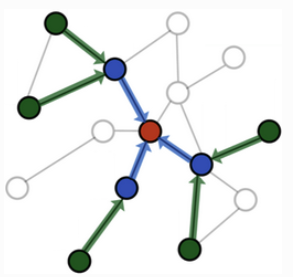

The key inputs to the `NeighborLoader` are:

*   input_nodes defines the set of seed nodes from which we want to start sampling from.
*   num_neighbors defines the number of neighbors to sample for each node in each hop.
*   batch_size defines the size of seed nodes we want to consider at once.

In [ ]:
train_loader = NeighborLoader(
    data,
    # Sample 25 neighbors for each node for the first iteration and 10 for the second
    num_neighbors=[25, 10],
    # Use a batch size of 128 for sampling training nodes
    batch_size=128,
    input_nodes=data.train_mask,
)

val_loader = NeighborLoader(
    data,
    # Sample 25 neighbors for each node for the first iteration and 10 for the second
    num_neighbors=[25, 10],
    # Use a batch size of 128 for sampling training nodes
    batch_size=128,
    input_nodes=data.val_mask,
)

test_loader = NeighborLoader(
    data,
    # Sample 25 neighbors for each node for the first iteration and 10 for the second
    num_neighbors=[25, 10],
    # Use a batch size of 128 for sampling training nodes
    batch_size=128,
    input_nodes=data.test_mask,
)

print(next(iter(test_loader)))
next(iter(test_loader))

## 3.3 The GraphSAGE model

Now that we have our neighbor loaders set, we can create our model. To keep things simple, we will create a two layer GNN where each layer is a [SAGEConv](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.SAGEConv.html#torch_geometric.nn.conv.SAGEConv) module that, by default, takes the mean of a node's neighbor embeddings during aggregation. However, unlike our model using GCNConv layers, here our node neighborhoods will the minibatches created with NeighborLoader which are subsets of the full node neighborhood. SAGEConv includes some additional features that you should review in the documentation. Finally, note that we will set the output dimension of the second SAGEConv layer to be the same as the number of classes in our dataset, so that we will not need a the linear projection layer we used in the previous exmaples - this only for simplicity, nothing about SAGEConv prevents us from using subsequent prediction head layers. 

In [ ]:
# Define SAGE model for large graphs
class SAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        self.convs.append(SAGEConv(hidden_channels, out_channels))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = x.relu_()
                x = F.dropout(x, p=0.5, training=self.training)
        return x

With our model defined, we can now train the model. Here we define `train` and `test` methods. As the neighbor loaders do most of the work, we don't really need the full capability of PyTorch Lightning for this model.

In [ ]:
# Training function
def train(model, train_loader):
    model.train()

    total_loss = total_correct = total_examples = 0
    for batch in train_loader:
        optimizer.zero_grad()
        y = batch.y[:batch.batch_size]
        y_hat = model(batch.x, batch.edge_index)[:batch.batch_size]
        loss = F.cross_entropy(y_hat, y)
        loss.backward()
        optimizer.step()

        total_loss += float(loss) * batch.batch_size
        total_correct += int((y_hat.argmax(dim=-1) == y).sum())
        total_examples += batch.batch_size

    return total_loss / total_examples, total_correct / total_examples

# Testing function
@torch.no_grad()
def test(model, loader):
    model.eval()
    total_correct = total_examples = 0
    all_preds = []
    all_targs = []
    for batch in loader:
        y = batch.y[:batch.batch_size]
        y_hat = model(batch.x, batch.edge_index)[:batch.batch_size]
        all_preds.extend(y_hat.argmax(dim=-1))
        all_targs.extend(y)
        total_correct += int((y_hat.argmax(dim=-1) == y).sum())
        total_examples += batch.batch_size

    return total_correct / total_examples, torch.vstack(all_preds), torch.vstack(all_targs)

We can now train the model. We will evaluate the validation loss at each epoch. As in the previous examples, we could use this to select tuning parameters such as the number of hidden channels. Notice that we follow the same paradigm of passing a data loader (here, its a NeighborLoader instance instead of a DataLoader instance), and train on the batches.

In [ ]:
# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

model = SAGE(
    in_channels=data.num_node_features,
    hidden_channels=256,
    out_channels=data.y.max().item() + 1,
).to(device)

# Move data to device
data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.003, weight_decay=5e-4)

# Training loop
print("\nStarting training...")
print("Epoch \t| \tTrain Loss | \tTrain Acc | \tVal Acc")
print("-" * 50)

for epoch in range(1, 11):
    loss, tacc = train(epoch, model, train_loader)
    vacc, _, _ = test(model, val_loader)
    print(f'Epoch {epoch:02d}, \t{loss:.4f}, \t{tacc:.4f}, \t{vacc:.4f}')
    # train_acc, val_acc, test_acc = test()
    # print(f'Epoch: {epoch:02d}, Train: {train_acc:.4f}, Val: {val_acc:.4f}, '
    #       f'Test: {test_acc:.4f}')

Finally, assuming we have selected our tuning parameters and final model architecture, we can evaluate performance on the test set.

In [ ]:
# test predictions and probabilities
model.eval()
_, y_pred, y_true = test(model, test_loader)
y_pred = y_pred.cpu().numpy()
y_true = y_true.cpu().numpy()
print("Classification Report:")
print(classification_report(y_true,y_pred,digits=4))

plot_confusion_matrix(y_true, y_pred, class_names=class_names, title="Confusion Matrix")